In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings
import time
import re
from bootstrap_mc_kalshi import *

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
pd.set_option({
    'display.max_rows':300,
    'display.max_columns':300,
    'display.max_colwidth':300
})

results = pd.read_csv("data/model_predictions/latest.csv").set_index('username')

Total Exposure:1519.64. Expected Revenue: 1829.4332. Net profits avg: 309.79. ROI 20.39%


,eventTitle,marketTitle,position,ROI,orderPrice,evPerShare,volume,cost,expectedValue,expectedReturn
18,Top 8,Arjun Erigaisi,Yes,1.48,0.221613,0.327347,530.00,117.45,$173.49,56.04
22,Top 8,Hans Niemann,Yes,1.46,0.179877,0.261965,558.00,100.37,$146.18,45.81
53,Top 1,Sina Movahed,Yes,1.43,0.053325,0.076074,100.00,5.33,$7.61,2.28
38,Top 3,Hans Niemann,Yes,1.36,0.085152,0.115693,245.00,20.86,$28.34,7.48
43,Top 3,Sina Movahed,Yes,1.35,0.106300,0.143959,552.00,58.68,$79.47,20.79
40,Top 3,Jan-Krzysztof Duda,Yes,1.31,0.127392,0.166656,305.00,38.85,$50.83,11.98
17,Top 8,Aleksei Sarana,Yes,1.31,0.304413,0.398537,306.00,93.15,$121.95,28.80
24,Top 8,Jan-Krzysztof Duda,Yes,1.27,0.232012,0.295573,311.00,72.16,$91.92,19.76
20,Top 8,Dmitry Andreikin,Yes,1.25,0.190332,0.237817,372.00,70.80,$88.47,17.67
30,Top 8,Parham Maghsoodloo,Yes,1.23,0.200773,0.246463,305.00,61.24,$75.17,13.93


  p_participate: decay-weighted EWMA with Isotonic Gaussian participation floor (@p < .05)
  231 events | 8,840 unique players | 2022-02-08 to 2026-07-14
  Player pool: 8,840
   10,000 / 20,000  (5.5s)
   20,000 / 20,000  (10.8s)

── Portfolio (20,000 simulated tournaments) ──────────────
  Mean        : $+291.91
  Std dev     : $558.91
  5th pctile  : $-611.76
  25th pctile : $-106.01
  Median      : $+276.24
  75th pctile : $+672.24
  95th pctile : $+1231.24
  Worst case  : $-1219.76
  Best case   : $+2381.24


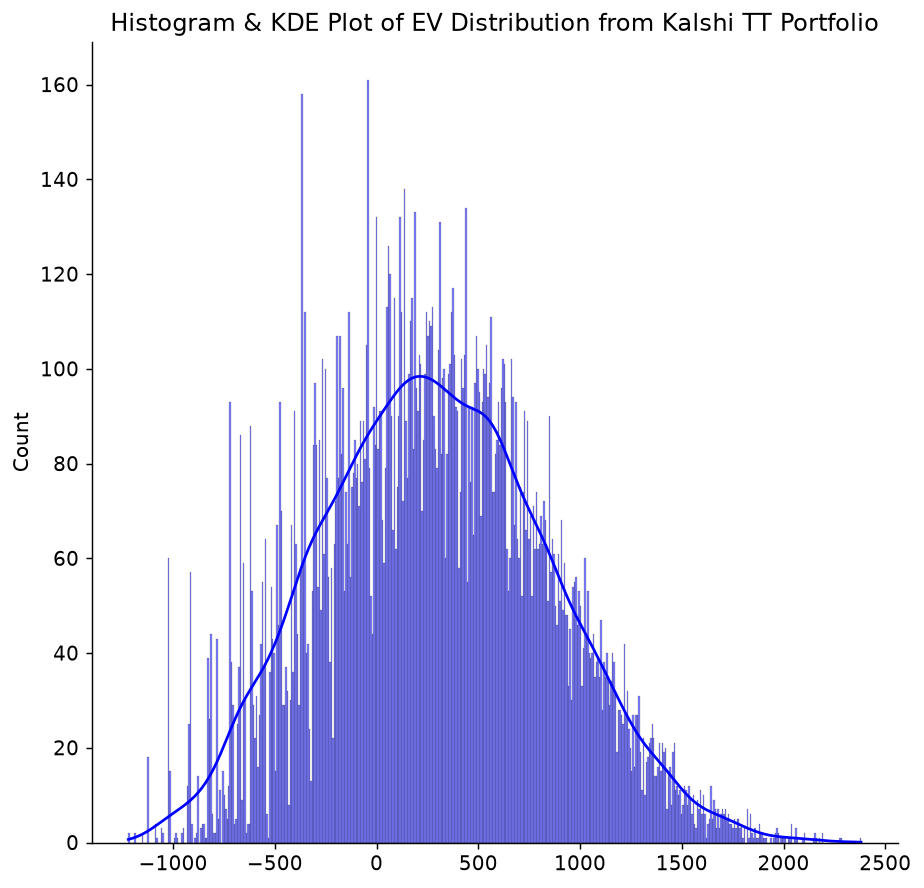

In [2]:
def display_profits(df_tt, df_results, verbose=False):
    costs = 0
    revenue = 0
    for idx, row in df_tt.iterrows():
        costs += row['cost']

        pos = 1.0 if row['position']=='Yes' else 0.0
        username = PLAYER_TO_USERNAME[row['marketTitle']][0]
        n = row['n']

        if not username in df_results.index:
            if verbose:
                print(f"{row['marketTitle']} in top {n}: {'YES' if result > 0 else 'NO'}. -${row['cost']}")
            continue

        result = df_results.loc[username, f'P_top{n}'].item()

        if result == pos:
            if verbose:
                print(f"{row['marketTitle']} in top {n}: {'YES' if result > 0 else 'NO'}. +${row['volume'] - row['cost']}")
            revenue += row['volume']
        else:
            if verbose:
                print(f"{row['marketTitle']} in top {n}: {'YES' if result > 0 else 'NO'}. -${row['cost']}")
            pass
    
    return revenue - costs

def avg_profits(df, df_results, fees=0, verbose=False):
    revenues = []
    costs = []
    values = []
    values_per_share = []
    for idx, row in df.iterrows():
        username = PLAYER_TO_USERNAME[row['marketTitle']]
        n = row['n']
        costs.append(round(row['volume']*row['orderPrice'],2))

        if not username in df_results.index:
            print(f"{row['marketTitle']} in top {n}\t\t{row['position'].upper()}:\tBought {row['volume']} @{row['orderPrice']:.2f}.\t0.0 EV per share.\t ${-row['cost']:.2f} EV\t {0:.2f}% ROI")
            revenues.append(0)
            continue

        result = df_results.loc[username, f'P_top{n}'].item()
        value = result if row['position']=='Yes' else (1-result)
        revenues.append(row['volume']*value)
        values.append(f'${value*row['volume']:.2f}')
        values_per_share.append(value)
        if verbose:
            print(f"{row['marketTitle']} in top {n}\t\t{row['position'].upper()}:\tBought {row['volume']} @{row['orderPrice']:.2f}.\t{value:.2f} EV per share.\t ${row['volume']*value-row['cost']:.2f} EV\t {(row['volume']*value/row['cost']-1)*100:.2f}% ROI")

    # Calculate ROI, EV for each position

    expected_return_col = [round(r-c,2) for r,c in zip(revenues, costs)]
    roi_col = [round(r/c,2) for r,c in zip(revenues, costs)]

    # Calculate Summary Statistics
    revenue = sum(revenues)
    cost = sum(costs)+fees
    net_profit = revenue-cost
    roi = (revenue/cost-1)*100

    print(f"Total Exposure:{cost}. Expected Revenue: {revenue}. Net profits avg: {net_profit:.2f}. ROI {roi:.2f}%")

    return expected_return_col, values, values_per_share, roi_col, costs

n_title_dict = {
    'Titled Tuesday Top 8: Jul 21': 8,
    'Titled Tuesday Top 3: Jul 21': 3,
    'Titled Tuesday Winner: Jul 21': 1
    }

# Building the Kalshi Portfolio DF
kalshi_orders = pd.read_csv("data/Kalshi-Advanced-Portfolio.csv")
df_tt = kalshi_orders[kalshi_orders['eventTitle'].str.contains('Tuesday')]
df_tt[['position','volume']] = df_tt['position'].str.split(' x ',expand=True)
df_tt['volume'] = df_tt['volume'].astype(float)
df_tt['n'] = df_tt['eventTitle'].apply(lambda x: n_title_dict[x])
df_tt['orderPrice'] = kalshi_order_price(df_tt['averagePrice'].str.extract('(\d+)').astype(float)/100.0)
df_tt['expectedReturn'], df_tt['expectedValue'], df_tt['evPerShare'], df_tt['ROI'], df_tt['cost']=avg_profits(df_tt, results)
df_tt['eventTitle'] = df_tt['eventTitle'].apply(lambda event: f'Top {n_title_dict[event]}')
display(df_tt[['eventTitle','marketTitle','position','ROI','orderPrice','evPerShare','volume','cost','expectedValue','expectedReturn']].sort_values('ROI',ascending=False))

from bootstrap_mc_kalshi import (
    load_and_prepare, build_player_pool,
    build_portfolio, run_portfolio_mc, pnl_summary,
)

df, p_participate, app_counts = load_and_prepare(
    cut_players=['Matthias Bluebaum','Levon Aronian','Yagiz Kaan Erdogmus','Jose Martinez','Le Quang Liem', 'Daniel Naroditsky'],
    attendance_model='decay'
)
players, p_play, hist_pcts, hist_wts = build_player_pool(df, p_participate, app_counts)
portfolio = build_portfolio(df_tt, players, PLAYER_TO_USERNAME)
pnl = run_portfolio_mc(players, p_play, hist_pcts, hist_wts, portfolio, n_sims=20_000)
pnl_summary(pnl)


fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        
sns.histplot(x=pnl, kde=True, ax=ax, color='blue', bins=500)

ax.set_title('Histogram & KDE Plot of EV Distribution from Kalshi TT Portfolio')

plt.show()
plt.close(fig)

In [3]:
BASE = "https://api.elections.kalshi.com/trade-api/v2"
event_tickers = ["KXTITLEDTUESDAY-26JUL21","KXTITLEDTUESTOP-26JUL21T3","KXTITLEDTUESTOP-26JUL21T8"]


markets = []
cursor = None
for event_ticker in event_tickers:
    while True:
        params = {"event_ticker": event_ticker, "status": "open", "limit": 200}
        if cursor:
            params["cursor"] = cursor
        resp = requests.get(f"{BASE}/markets", params=params)
        resp.raise_for_status()
        data = resp.json()
        markets.extend(data.get("markets", []))
        cursor = data.get("cursor")
        if not cursor:
            break

all_asks= []

if markets:
    print(f"Found {len(markets)} markets in events '{[event_ticker for event_ticker in event_tickers]}'. Fetching rates...")

    for market in markets:
        ticker = market["ticker"]
        title = market.get("title", "")
        subtitle = market.get("yes_sub_title", "")

        ob_resp = requests.get(f"{BASE}/markets/{ticker}/orderbook")

        if ob_resp.status_code == 200:
            ob = ob_resp.json().get("orderbook_fp") or {}
            # Resting NO bids: each [price, qty] NO bid implies
            # YES is for sale at (1.00 - no_price) for that quantity.
            yes_levels = ob.get("yes_dollars") or []
            no_levels = ob.get("no_dollars") or []

            for price_str, qty_str in yes_levels:
                no_ask = float("1.00") - float(price_str)
                all_asks.append({
                    "Market Ticker": ticker,
                    "Market Title": title,
                    "Player Name": subtitle,
                    "Ask Price ($)": float(no_ask),
                    "Quantity Available": float(qty_str),
                    "Side": "NO"
                })
            for price_str, qty_str in no_levels:
                yes_ask = float("1.00") - float(price_str)
                all_asks.append({
                    "Market Ticker": ticker,
                    "Market Title": title,
                    "Player Name": subtitle,
                    "Ask Price ($)": float(yes_ask),
                    "Quantity Available": float(qty_str),
                    "Side": "YES"
                })
        else:
            print(f"Could not retrieve orderbook for {ticker} "
                  f"(HTTP {ob_resp.status_code})")

        time.sleep(0.05)  # stay under public rate limits

Found 156 markets in events '['KXTITLEDTUESDAY-26JUL21', 'KXTITLEDTUESTOP-26JUL21T3', 'KXTITLEDTUESTOP-26JUL21T8']'. Fetching rates...


In [4]:
results = pd.read_csv("data/model_predictions/latest.csv").set_index('username')
dfk = pd.DataFrame(all_asks)
dfk['n'] = dfk['Market Title'].apply(lambda s: re.search(r'\d+',s).group())

dfk['username'] = dfk['Player Name'].apply(lambda n: PLAYER_TO_USERNAME[n])
evs = []
order_prices=[]
for _, row in dfk.iterrows():
    n = 1 if row['n'] == '21' else int(row['n'])
    p_yes = (results.loc[row['username'], f'P_top{n}'].item())
    evs.append(p_yes if row['Side']=='YES' else (1-p_yes))

dfk['EV'] = evs
dfk['Order Price'] = (dfk['Ask Price ($)'] + 0.07 * dfk['Ask Price ($)'] * (1.0 - dfk['Ask Price ($)']))
dfk['Total Cost'] = dfk['Quantity Available']*dfk['Order Price']
dfk['Expected Return'] = ((dfk['EV']-dfk['Order Price'])*dfk['Quantity Available'].astype(int))
dfk['ROI'] = round(dfk['EV']/dfk['Order Price'].astype(float),3)
dfk = dfk[dfk['ROI']>1.]
print(dfk['Expected Return'].sum())
dfk[['Market Title','ROI','Side','Order Price','EV','Quantity Available','Total Cost','Expected Return']][(dfk['ROI']>1.)].sort_values('ROI',ascending=False)

294.14991900000007


,Market Title,ROI,Side,Order Price,EV,Quantity Available,Total Cost,Expected Return
512,"Will Sina Movahed finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.354,YES,0.106300,0.143959,191.00,20.303300,7.192869
1302,"Will Arjun Erigaisi finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",1.295,YES,0.252768,0.327347,200.23,50.611737,14.915800
724,"Will Denis Lazavik finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.277,YES,0.148428,0.189566,87.00,12.913236,3.579006
1205,"Will Dmitry Andreikin finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",1.249,YES,0.190332,0.237817,224.17,42.666724,10.636640
511,"Will Sina Movahed finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.232,YES,0.116853,0.143959,100.00,11.685300,2.710600
777,"Will Aleksei Sarana finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.209,YES,0.148428,0.179450,201.00,29.834028,6.235422
673,"Will Hans Niemann finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.208,YES,0.095733,0.115693,180.00,17.231940,3.592800
1301,"Will Arjun Erigaisi finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",1.197,YES,0.273468,0.327347,100.00,27.346800,5.387900
723,"Will Denis Lazavik finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.193,YES,0.158925,0.189566,100.00,15.892500,3.064100
1259,"Will Aleksei Sarana finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",1.189,YES,0.335232,0.398537,5.00,1.676160,0.316525


In [5]:
# ── Simple (single-bet) Kelly sizing ─────────────────────────────────────────
# f* = (p - c) / (1 - c)  where p = model probability, c = cost per share
# Applied independently per position then normalised if total > 1.
# Use KELLY_MULT < 1 (half-Kelly = 0.5 recommended) to account for model error.

BANKROLL   = 1710   # <-- set to your actual bankroll in $
KELLY_MULT = 0.5    # half-Kelly

df_pos = dfk[dfk['ROI'] > 1.0].copy()

# Raw single-bet Kelly fraction: optimal bankroll fraction if this were the only bet
df_pos['kelly_f'] = (df_pos['EV'] - df_pos['Order Price']) / (1.0 - df_pos['Order Price'])

# If the sum of independent Kelly fractions exceeds 1, the positions collectively
# need more than the full bankroll.  Normalise proportionally as a conservative
# approximation for correlated simultaneous bets.
total_f = df_pos['kelly_f'].sum()
if total_f > 1.0:
    print(f"Sum of single-bet Kelly fractions = {total_f:.2f} — normalising to 1.0")
    df_pos['kelly_f'] /= total_f

# alloc_frac: final fraction of bankroll deployed to each position
# = normalised kelly_f * KELLY_MULT
df_pos['alloc_frac']   = df_pos['kelly_f'] * KELLY_MULT
df_pos['kelly_shares'] = (df_pos['alloc_frac'] * BANKROLL / df_pos['Order Price']).round().clip(lower=0).astype(int)
df_pos['kelly_cost']   = df_pos['kelly_shares'] * df_pos['Order Price']
df_pos['kelly_ev']     = df_pos['kelly_shares'] * df_pos['EV']
df_pos['kelly_edge']   = df_pos['kelly_ev'] - df_pos['kelly_cost']

df_kelly = df_pos[df_pos['kelly_shares'] > 0].copy()

total_cost = df_kelly['kelly_cost'].sum()
total_ev   = df_kelly['kelly_ev'].sum()
print(f"Bankroll ${BANKROLL:,.0f}  |  Exposure ${total_cost:.0f} ({total_cost/BANKROLL*100:.1f}%)  |  "
      f"Expected edge ${total_ev - total_cost:.2f}  |  Portfolio ROI {(total_ev/total_cost - 1)*100:.1f}%\n")

df_kelly[['Market Title', 'Side', 'ROI', 'Order Price', 'EV', 'kelly_f', 'alloc_frac', 'kelly_shares', 'kelly_cost', 'kelly_edge']]\
    .sort_values('kelly_f', ascending=False)\
    .style.format({'Order Price': '{:.3f}', 'EV': '{:.3f}', 'kelly_f': '{:.4f}', 'alloc_frac': '{:.4f}',
                   'kelly_cost': '${:.2f}', 'kelly_edge': '${:.2f}'})

Sum of single-bet Kelly fractions = 23.72 — normalising to 1.0
Bankroll $1,710  |  Exposure $856 (50.0%)  |  Expected edge $38.25  |  Portfolio ROI 4.5%



,Market Title,Side,ROI,Order Price,EV,kelly_f,alloc_frac,kelly_shares,kelly_cost,kelly_edge
638,"Will Jose Martinez finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.029000,0.972,1.000,0.0422,0.0211,37,$35.97,$1.03
639,"Will Jose Martinez finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.039000,0.963,1.000,0.0422,0.0211,37,$35.62,$1.38
1075,"Will Jose Martinez finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.103000,0.906,1.000,0.0422,0.0211,40,$36.25,$3.75
1074,"Will Jose Martinez finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.092000,0.916,1.000,0.0422,0.0211,39,$35.71,$3.29
1073,"Will Jose Martinez finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.019000,0.981,1.000,0.0422,0.0211,37,$36.31,$0.69
1033,"Will Levon Aronian finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.029000,0.972,1.000,0.0422,0.0211,37,$35.97,$1.03
1034,"Will Levon Aronian finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.039000,0.963,1.000,0.0422,0.0211,37,$35.62,$1.38
1015,"Will Matthias Bluebaum finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.039000,0.963,1.000,0.0422,0.0211,37,$35.62,$1.38
1016,"Will Matthias Bluebaum finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.049000,0.953,1.000,0.0422,0.0211,38,$36.23,$1.77
1072,"Will Jose Martinez finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.009000,0.991,1.000,0.0422,0.0211,36,$35.66,$0.34


In [6]:
df, p_participate, app_counts = load_and_prepare(
    cut_players=['Matthias Bluebaum','Levon Aronian','Yagiz Kaan Erdogmus','Jose Martinez','Le Quang Liem', 'Daniel Naroditsky'],
    attendance_model='decay',
)
players, p_play, hist_pcts, hist_wts = build_player_pool(df, p_participate, app_counts)

  p_participate: decay-weighted EWMA with Isotonic Gaussian participation floor (@p < .05)
  231 events | 8,840 unique players | 2022-02-08 to 2026-07-14
  Player pool: 8,840


In [7]:
# ── Portfolio Kelly optimisation (MC-based) ───────────────────────────────────
# Maximises E[log(bankroll + PnL)] over share counts, accounting for the
# correlation structure of chess outcomes discovered by the simulation.
# This is strictly better than simple Kelly when bets are correlated.

from bootstrap_mc_kalshi import run_payoff_matrix, portfolio_kelly

# Build a 1-share-per-position portfolio from every positive-EV orderbook entry.
# run_payoff_matrix returns the per-share payoff, so the optimizer works in
# share units and the cost constraint keeps total exposure <= kelly_fraction * bankroll.
df_cands = dfk[dfk['ROI'] > 1.0].copy()
df_cands['n_int'] = df_cands['n'].apply(lambda x: 1 if str(x) == '21' else int(x))

# Drop the original string 'n' column before renaming n_int -> n to avoid
# duplicate column names (which cause port_n to be 2D in build_portfolio).
df_cands_fmt = (
    df_cands
    .drop(columns=['n'])
    .rename(columns={'Player Name': 'marketTitle', 'Side': 'position', 'n_int': 'n'})
    .copy()
)
df_cands_fmt['position'] = df_cands_fmt['position'].str.title()   # YES -> Yes, NO -> No
df_cands_fmt['volume']   = 1.0                                      # 1 share = unit for payoff matrix
df_cands_fmt['cost']     = df_cands_fmt['Order Price']             # cost per share

portfolio_cands = build_portfolio(df_cands_fmt, players, PLAYER_TO_USERNAME)

print("Running payoff matrix simulation (50k sims)...")
payoff_matrix, cost_per_share = run_payoff_matrix(
    players, p_play, hist_pcts, hist_wts,
    portfolio_cands, n_sims=50_000,
)

print("\nOptimising Kelly allocation...")
opt_shares, opt_result = portfolio_kelly(
    payoff_matrix, cost_per_share,
    bankroll=BANKROLL, kelly_fraction=KELLY_MULT,
)

df_cands['opt_shares'] = opt_shares
df_cands['opt_cost']   = opt_shares * df_cands['Order Price']
df_cands['opt_ev']     = opt_shares * df_cands['EV']
df_cands['opt_edge']   = df_cands['opt_ev'] - df_cands['opt_cost']

df_opt = df_cands[df_cands['opt_shares'] > 0].copy()
total_cost_opt = df_opt['opt_cost'].sum()
total_ev_opt   = df_opt['opt_ev'].sum()
print(f"\nPortfolio Kelly  |  Exposure ${total_cost_opt:.0f} ({total_cost_opt/BANKROLL*100:.1f}%)  |  "
      f"Expected edge ${total_ev_opt - total_cost_opt:.2f}  |  ROI {(total_ev_opt/total_cost_opt - 1)*100:.1f}%\n")

df_opt[['Market Title', 'Side', 'ROI', 'Order Price', 'EV', 'opt_shares', 'opt_cost', 'opt_edge']]\
    .sort_values('opt_shares', ascending=False)\
    .style.format({'Order Price': '{:.3f}', 'EV': '{:.3f}',
                   'opt_cost': '${:.2f}', 'opt_edge': '${:.2f}'})

Running payoff matrix simulation (50k sims)...
   10,000 / 50,000  (5.3s)
   20,000 / 50,000  (10.7s)
   30,000 / 50,000  (15.8s)
   40,000 / 50,000  (20.9s)
   50,000 / 50,000  (26.1s)

Optimising Kelly allocation...
Converged: True  |  Exposure $855.00 (50.0% of bankroll)  |  E[log-return]: 0.0645

Portfolio Kelly  |  Exposure $855 (50.0%)  |  Expected edge $145.50  |  ROI 17.0%



,Market Title,Side,ROI,Order Price,EV,opt_shares,opt_cost,opt_edge
1205,"Will Dmitry Andreikin finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.249000,0.190,0.238,473,$90.03,$22.46
512,"Will Sina Movahed finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.354000,0.106,0.144,445,$47.30,$16.76
1075,"Will Jose Martinez finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.103000,0.906,1.000,375,$339.86,$35.14
1302,"Will Arjun Erigaisi finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.295000,0.253,0.327,347,$87.71,$25.88
724,"Will Denis Lazavik finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.277000,0.148,0.190,321,$47.65,$13.21
673,"Will Hans Niemann finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.208000,0.096,0.116,228,$21.83,$4.55
1259,"Will Aleksei Sarana finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.189000,0.335,0.399,168,$56.32,$10.64
845,"Will Vladislav Artemiev finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.099000,0.887,0.976,131,$116.25,$11.56
1094,"Will Jan-Krzysztof Duda finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.081000,0.273,0.296,84,$22.97,$1.86
553,"Will Parham Maghsoodloo finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.088000,0.106,0.116,70,$7.44,$0.66


In [8]:
# ── A: Recommended additional buys to reach Kelly-optimal sizing ──────────────
# Compares the portfolio Kelly target (opt_shares) for each position against
# shares already held in df_tt, then recommends the difference.
# Positions not yet held at all are treated as 0 shares held.

# Sum existing shares per (player_name, n, side) across all df_tt rows
held = (
    df_tt
    .assign(side_up=df_tt['position'].str.upper())
    .groupby(['marketTitle', 'n', 'side_up'])['volume']
    .sum()
)  # MultiIndex Series: (marketTitle, n, side_up) -> total shares held

def shares_held(player_name, n_int, side):
    try:
        return held.loc[(player_name, n_int, side)]
    except KeyError:
        return 0.0

df_buys = df_opt.copy()
df_buys['held']              = df_buys.apply(lambda r: shares_held(r['Player Name'], r['n_int'], r['Side']), axis=1)
df_buys['additional_shares'] = (df_buys['opt_shares'] - df_buys['held']).clip(lower=0).astype(int)
df_buys['additional_cost']   = df_buys['additional_shares'] * df_buys['Order Price']
df_buys['additional_ev']     = df_buys['additional_shares'] * df_buys['EV']
df_buys['additional_edge']   = df_buys['additional_ev'] - df_buys['additional_cost']

df_new_buys = df_buys[df_buys['additional_shares'] > 0].copy()

total_new_cost = df_new_buys['additional_cost'].sum()
total_new_ev   = df_new_buys['additional_ev'].sum()
print(f"Recommended buys  |  Additional exposure ${total_new_cost:.0f}  |  "
      f"Expected edge ${total_new_ev - total_new_cost:.2f}  |  "
      f"ROI {(total_new_ev / total_new_cost - 1)*100:.1f}%\n")

df_new_buys[['Market Title', 'Side', 'ROI', 'Order Price', 'EV', 'held', 'opt_shares', 'additional_shares', 'additional_cost', 'additional_edge']]\
    .sort_values('additional_edge', ascending=False)\
    .style.format({'Order Price': '{:.3f}', 'EV': '{:.3f}',
                   'additional_cost': '${:.2f}', 'additional_edge': '${:.2f}'})

Recommended buys  |  Additional exposure $267  |  Expected edge $33.87  |  ROI 12.7%



,Market Title,Side,ROI,Order Price,EV,held,opt_shares,additional_shares,additional_cost,additional_edge
1075,"Will Jose Martinez finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.103000,0.906,1.000,200.880000,375,174,$157.70,$16.30
724,"Will Denis Lazavik finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.277000,0.148,0.190,171.000000,321,150,$22.26,$6.17
845,"Will Vladislav Artemiev finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,1.099000,0.887,0.976,66.000000,131,65,$57.68,$5.74
1205,"Will Dmitry Andreikin finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.249000,0.190,0.238,372.000000,473,101,$19.22,$4.80
553,"Will Parham Maghsoodloo finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,1.088000,0.106,0.116,13.000000,70,57,$6.06,$0.53
260,"Will Jan-Krzysztof Duda win the Titled Tuesday weekly chess competition, originally scheduled for Jul 21, 2026 at 11:00am EDT?",YES,1.087000,0.064,0.070,0.000000,58,58,$3.71,$0.32


In [9]:
# ── B: Maker bid orders for recommended buys ─────────────────────────────────
# Places limit orders 1 cent below the current ask, qualifying for the lower
# maker fee (1.75% vs 7%).  Drops any position where the lower bid price
# makes the trade negative EV after the maker fee is applied.

df_maker = df_new_buys.copy()
df_maker['maker_ask']         = (df_maker['Ask Price ($)'] - 0.01).clip(lower=0.01).round(2)
df_maker['maker_order_price'] = kalshi_order_price(df_maker['maker_ask'], make=True)
df_maker['maker_roi']         = df_maker['EV'] / df_maker['maker_order_price']
df_maker['maker_edge_share']  = df_maker['EV'] - df_maker['maker_order_price']
df_maker['maker_total_cost']  = df_maker['additional_shares'] * df_maker['maker_order_price']
df_maker['maker_total_edge']  = df_maker['additional_shares'] * df_maker['maker_edge_share']

# Taker vs maker cost savings per position
df_maker['fee_saving']        = df_maker['additional_shares'] * (df_maker['Order Price'] - df_maker['maker_order_price'])

df_maker = df_maker[df_maker['maker_roi'] > 1.0].copy()

total_maker_cost = df_maker['maker_total_cost'].sum()
total_maker_ev   = df_maker['maker_total_cost'].sum() + df_maker['maker_total_edge'].sum()
total_fee_saving = df_maker['fee_saving'].sum()
print(f"Maker orders  |  Total cost ${total_maker_cost:.0f}  |  "
      f"Expected edge ${df_maker['maker_total_edge'].sum():.2f}  |  "
      f"ROI {(total_maker_ev / total_maker_cost - 1)*100:.1f}%  |  "
      f"Fee saving vs taker ${total_fee_saving:.2f}\n")

df_maker[['Market Ticker','Market Title', 'Side', 'Ask Price ($)', 'maker_ask', 'maker_order_price', 'EV',
          'maker_roi', 'additional_shares', 'maker_total_cost', 'maker_total_edge', 'fee_saving']]\
    .sort_values('Market Ticker', ascending=False)\
    .style.format({'Ask Price ($)': '{:.2f}', 'maker_ask': '{:.2f}', 'maker_order_price': '{:.3f}',
                   'EV': '{:.3f}', 'maker_roi': '{:.3f}',
                   'maker_total_cost': '${:.2f}', 'maker_total_edge': '${:.2f}',
                   'fee_saving': '${:.2f}'})

Maker orders  |  Total cost $257  |  Expected edge $43.29  |  ROI 16.8%  |  Fee saving vs taker $9.42



,Market Ticker,Market Title,Side,Ask Price ($),maker_ask,maker_order_price,EV,maker_roi,additional_shares,maker_total_cost,maker_total_edge,fee_saving
845,KXTITLEDTUESTOP-26JUL21T8-VART,"Will Vladislav Artemiev finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,0.88,0.87,0.872,0.976,1.119,65,$56.68,$6.74,$1.00
1075,KXTITLEDTUESTOP-26JUL21T8-JMAR,"Will Jose Martinez finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",NO,0.90,0.89,0.892,1.000,1.121,174,$155.16,$18.84,$2.54
1205,KXTITLEDTUESTOP-26JUL21T8-DAND,"Will Dmitry Andreikin finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,0.18,0.17,0.172,0.238,1.379,101,$17.42,$6.60,$1.80
553,KXTITLEDTUESTOP-26JUL21T3-PMAG,"Will Parham Maghsoodloo finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,0.10,0.09,0.091,0.116,1.265,57,$5.21,$1.38,$0.85
724,KXTITLEDTUESTOP-26JUL21T3-DLAZ,"Will Denis Lazavik finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",YES,0.14,0.13,0.132,0.190,1.436,150,$19.80,$8.64,$2.47
260,KXTITLEDTUESDAY-26JUL21-JDUD,"Will Jan-Krzysztof Duda win the Titled Tuesday weekly chess competition, originally scheduled for Jul 21, 2026 at 11:00am EDT?",YES,0.06,0.05,0.051,0.070,1.368,58,$2.95,$1.08,$0.76
